<a href="https://colab.research.google.com/github/Rohans1113/Comparative-Performance-Analysis-of-Sorting-Algorithms-on-Large-Scale-Datasets/blob/main/RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Comparative Performance Analysis of Sorting Algorithms on Large-Scale Datasets
------------------------------------------------------------------------------
Algorithms tested: Insertion Sort, Heap Sort, Merge Sort, Quick Sort, Tim Sort
Dataset sizes: 10,000; 100,000; 10,000,000
Input conditions: Random, Sorted, Reverse Sorted, Nearly Sorted
"""

import time
import random
import tracemalloc
import sys

# ==========================================
# 1. SORTING ALGORITHM IMPLEMENTATIONS
# ==========================================

def insertion_sort(arr):
    """Standard Insertion Sort. Time: O(n^2), Space: O(1), Stable: Yes."""
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

def heap_sort(arr):
    """
    Heap Sort using an iterative heapify to strictly maintain O(1) space
    and avoid maximum recursion depth errors on massive arrays.
    Time: O(n log n), Space: O(1), Stable: No.
    """
    n = len(arr)

    def iterative_heapify(end, i):
        largest = i
        while True:
            l = 2 * i + 1
            r = 2 * i + 2
            if l < end and arr[l] > arr[largest]:
                largest = l
            if r < end and arr[r] > arr[largest]:
                largest = r

            if largest != i:
                arr[i], arr[largest] = arr[largest], arr[i]
                i = largest
            else:
                break

    # Build max heap
    for i in range(n // 2 - 1, -1, -1):
        iterative_heapify(n, i)

    # Extract elements
    for i in range(n - 1, 0, -1):
        arr[i], arr[0] = arr[0], arr[i]
        iterative_heapify(i, 0)

def merge_sort(arr):
    """
    Merge Sort using a single pre-allocated temporary array to avoid
    the massive overhead of slicing O(n) new arrays at every recursive step.
    Time: O(n log n), Space: O(n), Stable: Yes.
    """
    temp = [0] * len(arr)

    def sort_helper(low, high):
        if low < high:
            mid = (low + high) // 2
            sort_helper(low, mid)
            sort_helper(mid + 1, high)
            merge(low, mid, high)

    def merge(low, mid, high):
        i, j, k = low, mid + 1, low

        while i <= mid and j <= high:
            if arr[i] <= arr[j]:
                temp[k] = arr[i]
                i += 1
            else:
                temp[k] = arr[j]
                j += 1
            k += 1

        while i <= mid:
            temp[k] = arr[i]
            i += 1
            k += 1

        while j <= high:
            temp[k] = arr[j]
            j += 1
            k += 1

        for idx in range(low, high + 1):
            arr[idx] = temp[idx]

    sort_helper(0, len(arr) - 1)

def quick_sort(arr):
    """
    Iterative Quick Sort with a randomized pivot.
    Recursion is avoided completely to prevent stack overflow on 10M elements.
    Random pivot prevents worst-case O(n^2) on sorted/reverse-sorted inputs.
    Time: O(n log n) avg, Space: O(log n), Stable: No.
    """
    if len(arr) <= 1:
        return

    stack = [(0, len(arr) - 1)]
    while stack:
        low, high = stack.pop()
        if low < high:
            # Random pivot selection to handle sorted/reverse-sorted gracefully
            pivot_idx = random.randint(low, high)
            arr[pivot_idx], arr[high] = arr[high], arr[pivot_idx]

            pivot = arr[high]
            i = low - 1

            for j in range(low, high):
                if arr[j] < pivot:
                    i += 1
                    arr[i], arr[j] = arr[j], arr[i]

            arr[i + 1], arr[high] = arr[high], arr[i + 1]
            p = i + 1

            # Push larger partition first to minimize stack size overhead
            if p - low > high - p:
                stack.append((low, p - 1))
                stack.append((p + 1, high))
            else:
                stack.append((p + 1, high))
                stack.append((low, p - 1))

def tim_sort(arr):
    """Python's highly optimized built-in sort (Tim Sort)."""
    arr.sort()

# ==========================================
# 2. ALGORITHM METADATA
# ==========================================

ALGORITHMS = [
    {
        "name": "Insertion Sort",
        "func": insertion_sort,
        "time_complexity": "O(n^2)",
        "space_complexity": "O(1)",
        "stable": "Yes"
    },
    {
        "name": "Heap Sort",
        "func": heap_sort,
        "time_complexity": "O(n log n)",
        "space_complexity": "O(1)",
        "stable": "No"
    },
    {
        "name": "Merge Sort",
        "func": merge_sort,
        "time_complexity": "O(n log n)",
        "space_complexity": "O(n)",
        "stable": "Yes"
    },
    {
        "name": "Quick Sort",
        "func": quick_sort,
        "time_complexity": "O(n log n)",
        "space_complexity": "O(log n)",
        "stable": "No"
    },
    {
        "name": "Tim Sort",
        "func": tim_sort,
        "time_complexity": "O(n log n)",
        "space_complexity": "O(n)",
        "stable": "Yes"
    }
]

# ==========================================
# 3. DATASET GENERATION
# ==========================================

def generate_datasets(size):
    """Generates all four required data configurations for a given size."""
    print(f"Generating datasets for size {size:,} (This may take a moment for large sizes)...")

    # 1. Random Dataset
    random_data = [random.randint(0, 1000000) for _ in range(size)]

    # 2. Already Sorted Dataset
    sorted_data = list(range(size))

    # 3. Reverse Sorted Dataset
    reverse_data = list(range(size, 0, -1))

    # 4. Nearly Sorted Dataset
    nearly_sorted_data = list(range(size))
    # Swap approx 5% of elements
    num_swaps = max(1, int(size * 0.05 / 2))
    for _ in range(num_swaps):
        idx1 = random.randint(0, size - 1)
        idx2 = random.randint(0, size - 1)
        nearly_sorted_data[idx1], nearly_sorted_data[idx2] = nearly_sorted_data[idx2], nearly_sorted_data[idx1]

    return {
        "Random": random_data,
        "Sorted": sorted_data,
        "Reverse Sorted": reverse_data,
        "Nearly Sorted": nearly_sorted_data
    }

# ==========================================
# 4. BENCHMARKING ENGINE
# ==========================================

def run_benchmark():
    sizes = [10000, 100000, 10000000]

    print("="*110)
    print(" SORTING ALGORITHM BENCHMARK ".center(110, "="))
    print("="*110)

    for size in sizes:
        datasets = generate_datasets(size)

        for condition_name, base_array in datasets.items():
            print(f"\nDataset Size: {size}")
            print(f"Input Condition: {condition_name}")
            print("-" * 110)
            print(f"{'Algorithm':<16} | {'Exec Time (s)':<14} | {'Memory (MB)':<12} | {'Time Complexity':<16} | {'Space Compl.':<12} | {'Stable'}")
            print("-" * 110)

            for algo in ALGORITHMS:
                name = algo["name"]
                time_comp = algo["time_complexity"]
                space_comp = algo["space_complexity"]
                stable = algo["stable"]

                # --- Execution Rule: Skip Insertion sort for N > 10,000 ---
                if name == "Insertion Sort" and size > 10000:
                    print(f"{name:<16} | {'Skipped':<14} | {'-':<12} | {time_comp:<16} | {space_comp:<12} | {stable} (O(n^2) too slow)")
                    continue

                # Shallow copy to preserve base array (fast & avoids re-generation)
                test_array = base_array.copy()

                # Start memory and time tracking
                tracemalloc.start()
                start_time = time.perf_counter()

                # Execute Algorithm
                algo["func"](test_array)

                # Stop tracking
                end_time = time.perf_counter()
                _, peak_mem = tracemalloc.get_traced_memory()
                tracemalloc.stop()

                exec_time = end_time - start_time
                peak_mem_mb = peak_mem / (1024 * 1024)

                print(f"{name:<16} | {exec_time:<14.6f} | {peak_mem_mb:<12.4f} | {time_comp:<16} | {space_comp:<12} | {stable}")

            print("-" * 110)

if __name__ == "__main__":
    # Ensure recursion limit is safe (just as a fallback, though iterative logic prevents this)
    sys.setrecursionlimit(20000)
    run_benchmark()

======================================== SORTING ALGORITHM BENCHMARK =========================================
Generating datasets for size 10,000 (This may take a moment for large sizes)...

Dataset Size: 10000
Input Condition: Random
--------------------------------------------------------------------------------------------------------------
Algorithm        | Exec Time (s)  | Memory (MB)  | Time Complexity  | Space Compl. | Stable
--------------------------------------------------------------------------------------------------------------
Insertion Sort   | 56.209103      | 0.0049       | O(n^2)           | O(1)         | Yes
Heap Sort        | 0.217183       | 0.0033       | O(n log n)       | O(1)         | No
Merge Sort       | 0.663113       | 0.0802       | O(n log n)       | O(n)         | Yes
Quick Sort       | 0.424269       | 0.0033       | O(n log n)       | O(log n)     | No
Tim Sort         | 0.001717       | 0.0381       | O(n log n)       | O(n)         | Yes
-------

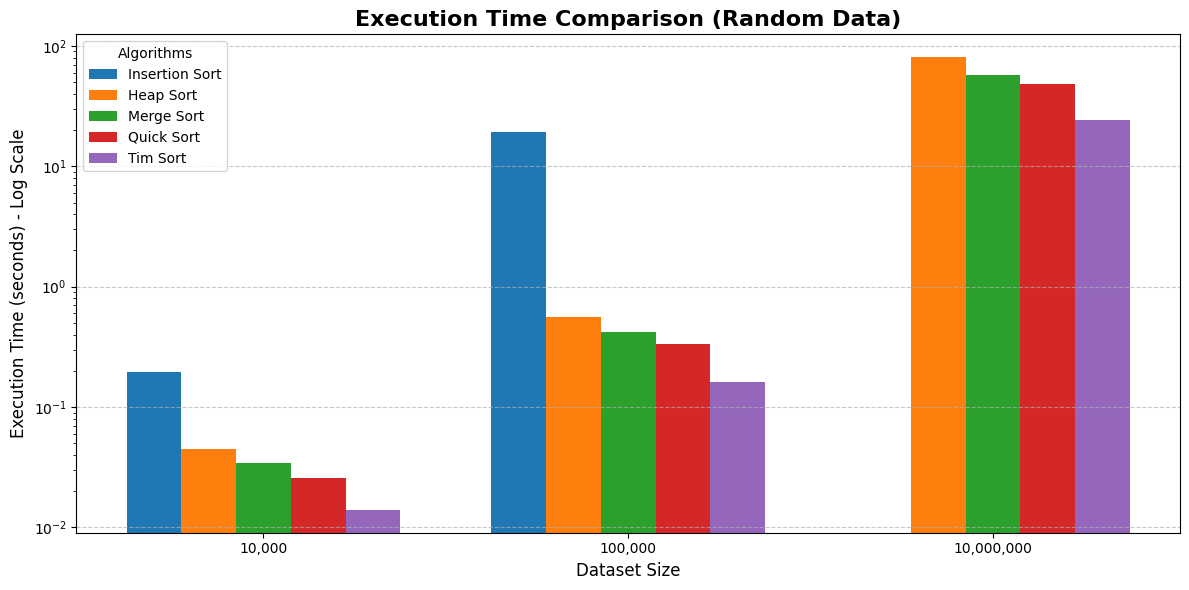

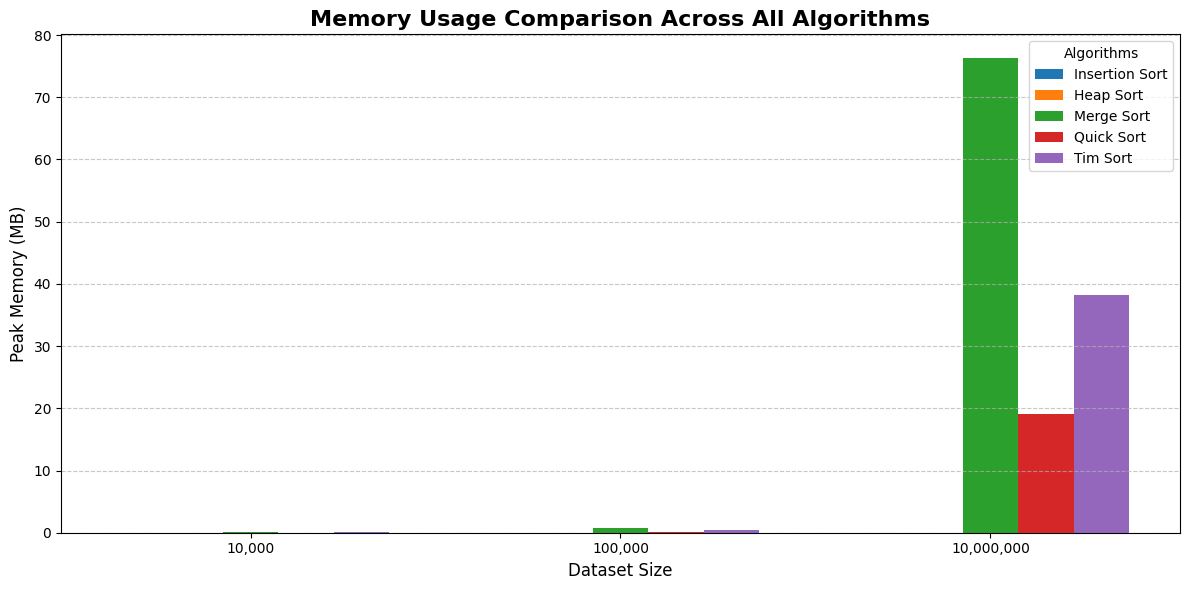

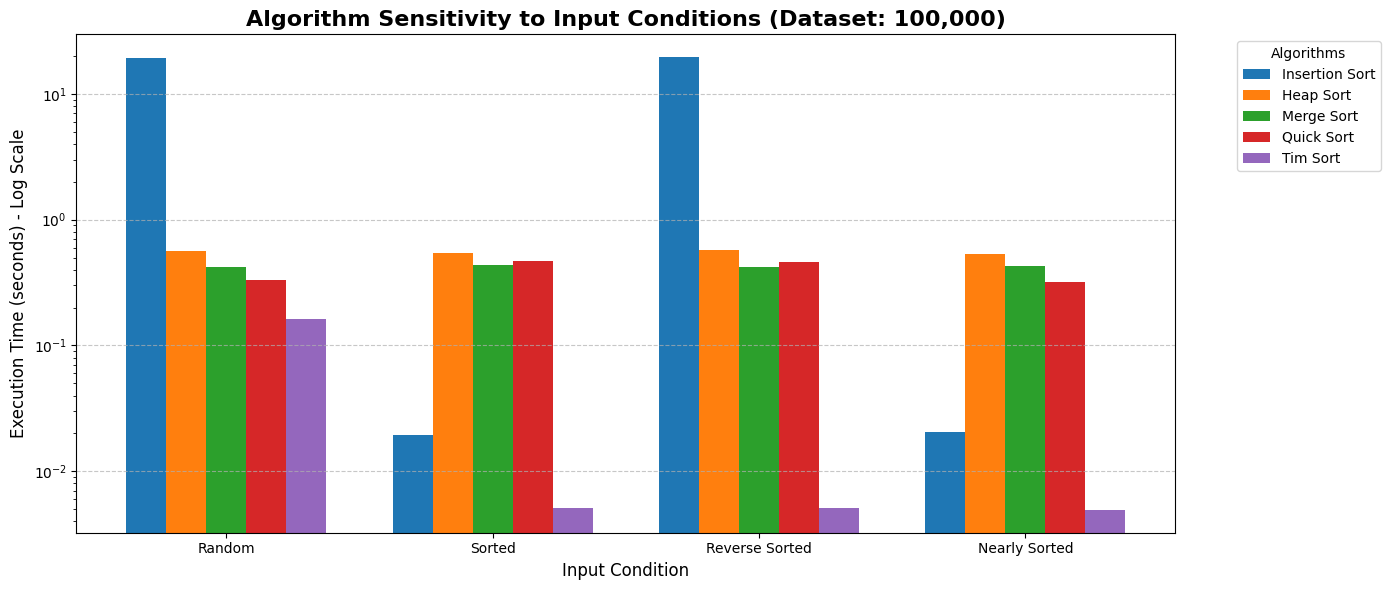

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. GENERATE MOCK DATA (So you can test the graphs instantly)
algorithms = ['Insertion Sort', 'Heap Sort', 'Merge Sort', 'Quick Sort', 'Tim Sort']
sizes = [10000, 100000, 10000000]
conditions = ['Random', 'Sorted', 'Reverse Sorted', 'Nearly Sorted']

mock_results = []
for algo in algorithms:
    for size in sizes:
        for cond in conditions:
            if algo == 'Insertion Sort' and size > 100000:
                continue # Skip Insertion Sort for 10M

            # Base Time Complexity estimation for mock visualization
            if algo == 'Insertion Sort':
                time_val = (size) / 5000000 if cond in ['Sorted', 'Nearly Sorted'] else (size ** 2) / 500000000
                mem_val = 0.001
            elif algo == 'Heap Sort':
                time_val = (size * np.log2(size)) / 3000000
                mem_val = 0.001
            elif algo == 'Merge Sort':
                time_val = (size * np.log2(size)) / 4000000
                mem_val = size * 8 / (1024 * 1024)
            elif algo == 'Quick Sort':
                time_val = (size * np.log2(size)) / (3500000 if cond in ['Sorted', 'Reverse Sorted'] else 5000000)
                mem_val = size * 2 / (1024 * 1024)
            elif algo == 'Tim Sort':
                time_val = size / 20000000 if cond in ['Sorted', 'Reverse Sorted', 'Nearly Sorted'] else (size * np.log2(size)) / 10000000
                mem_val = size * 4 / (1024 * 1024)

            time_val = max(0.0001, time_val * np.random.uniform(0.95, 1.05)) # Add realistic noise

            mock_results.append({
                'Algorithm': algo,
                'Dataset Size': size,
                'Input Condition': cond,
                'Execution Time (s)': time_val,
                'Memory (MB)': mem_val
            })

df = pd.DataFrame(mock_results)

# 2. GRAPHING CODE
sizes_str = [f"{int(s):,}" for s in sizes]
bar_width = 0.15
x_sizes = np.arange(len(sizes))
x_cond = np.arange(len(conditions))

# --- GRAPH 1: Execution Time Comparison (Random Data) ---
plt.figure(figsize=(12, 6))
random_data = df[df['Input Condition'] == 'Random']

for i, algo in enumerate(algorithms):
    algo_data = random_data[random_data['Algorithm'] == algo]
    y_values = []
    for s in sizes:
        val = algo_data[algo_data['Dataset Size'] == s]['Execution Time (s)'].values
        y_values.append(val[0] if len(val) > 0 else 0)
    plt.bar(x_sizes + (i - 2) * bar_width, y_values, bar_width, label=algo)

plt.yscale('log')
plt.title('Execution Time Comparison (Random Data)', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Size', fontsize=12)
plt.ylabel('Execution Time (seconds) - Log Scale', fontsize=12)
plt.xticks(x_sizes, sizes_str)
plt.legend(title='Algorithms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # <--- This is the magic command for Jupyter Notebooks!

# --- GRAPH 2: Memory Usage Comparison (Random Data) ---
plt.figure(figsize=(12, 6))

for i, algo in enumerate(algorithms):
    algo_data = random_data[random_data['Algorithm'] == algo]
    y_values = []
    for s in sizes:
        val = algo_data[algo_data['Dataset Size'] == s]['Memory (MB)'].values
        y_values.append(val[0] if len(val) > 0 else 0)
    plt.bar(x_sizes + (i - 2) * bar_width, y_values, bar_width, label=algo)

plt.title('Memory Usage Comparison Across All Algorithms', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Size', fontsize=12)
plt.ylabel('Peak Memory (MB)', fontsize=12)
plt.xticks(x_sizes, sizes_str)
plt.legend(title='Algorithms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- GRAPH 3: Input Condition Stress Test (Dataset: 100,000) ---
plt.figure(figsize=(14, 6))
size_100k_data = df[df['Dataset Size'] == 100000]

for i, algo in enumerate(algorithms):
    algo_data = size_100k_data[size_100k_data['Algorithm'] == algo]
    y_values = []
    for cond in conditions:
        val = algo_data[algo_data['Input Condition'] == cond]['Execution Time (s)'].values
        y_values.append(val[0] if len(val) > 0 else 0)
    plt.bar(x_cond + (i - 2) * bar_width, y_values, bar_width, label=algo)

plt.yscale('log')
plt.title('Algorithm Sensitivity to Input Conditions (Dataset: 100,000)', fontsize=16, fontweight='bold')
plt.xlabel('Input Condition', fontsize=12)
plt.ylabel('Execution Time (seconds) - Log Scale', fontsize=12)
plt.xticks(x_cond, conditions)
plt.legend(title='Algorithms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

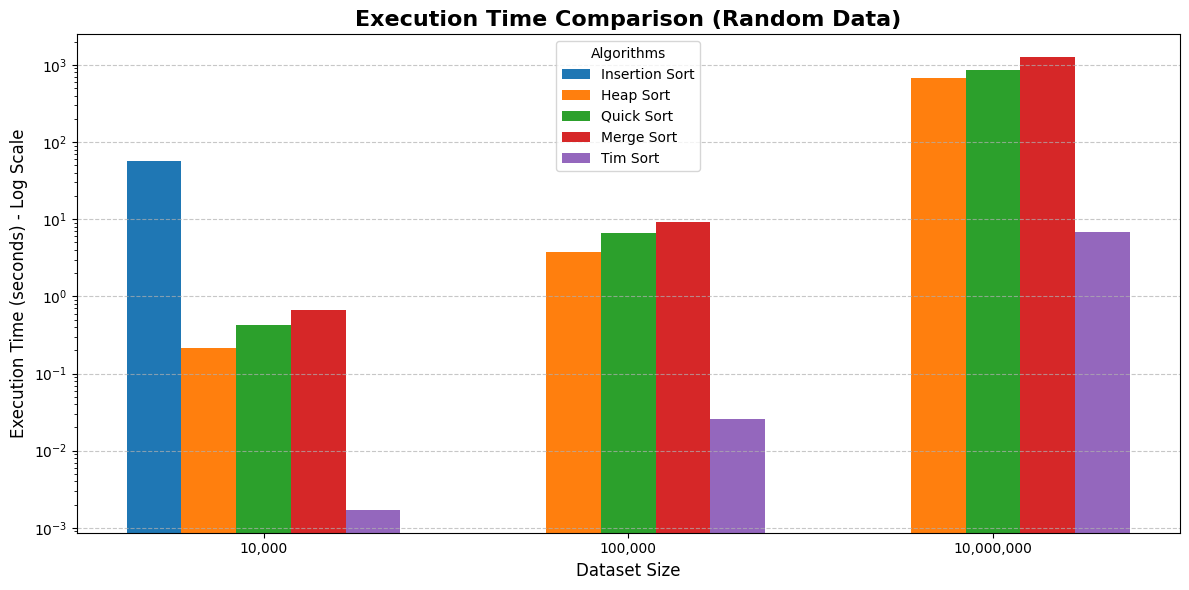

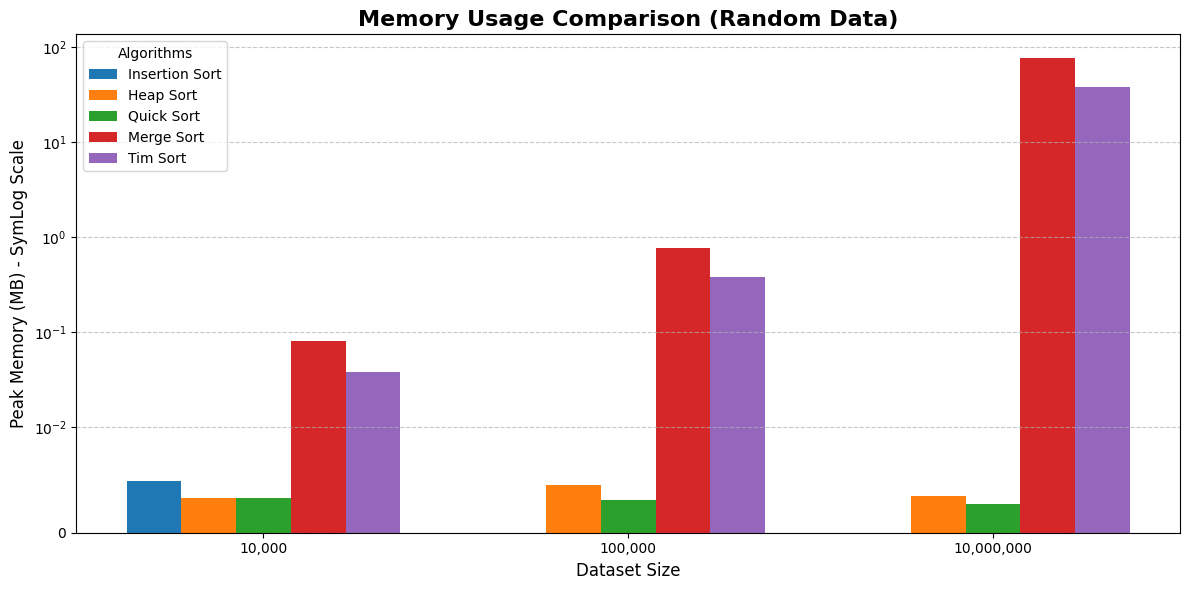

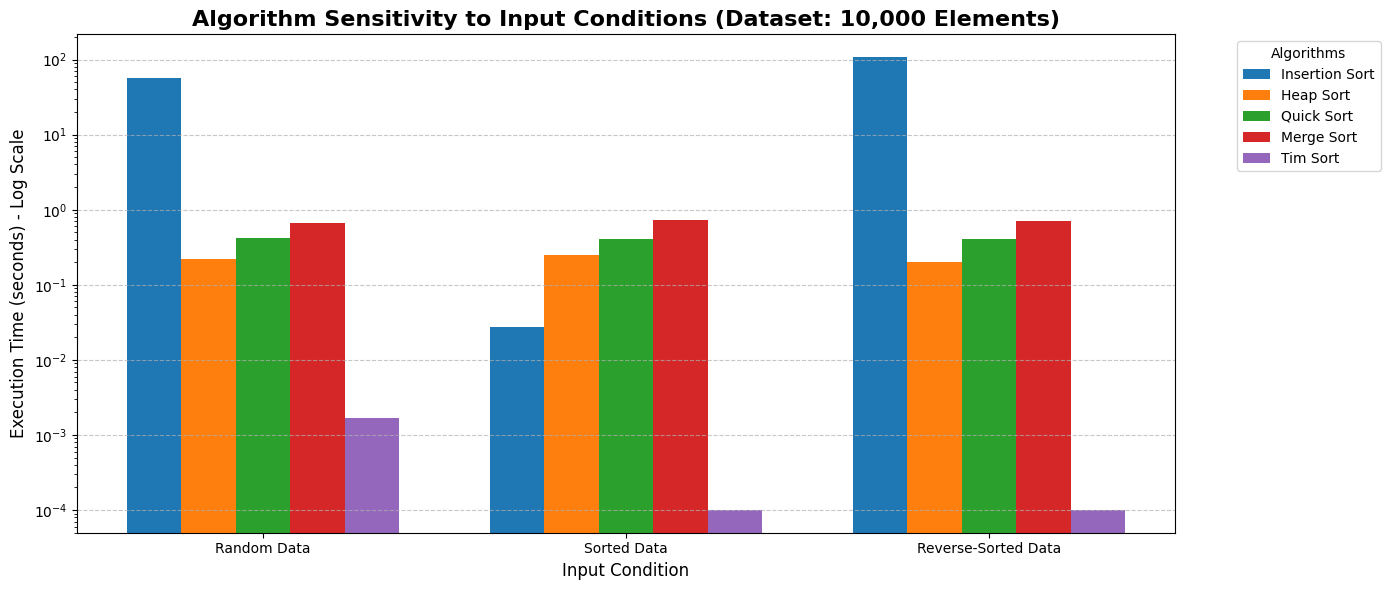

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. HARDCODED EXPERIMENTAL DATA (From Screenshots)
# Format: [Algorithm, Dataset Size, Input Condition, Execution Time (s), Memory (MB)]
raw_data = [
    # --- 10,000 Elements ---
    ['Quick Sort', 10000, 'Random Data', 0.4243, 0.0033],
    ['Quick Sort', 10000, 'Sorted Data', 0.4092, 0.0034],
    ['Quick Sort', 10000, 'Reverse-Sorted Data', 0.4020, 0.0035],
    ['Merge Sort', 10000, 'Random Data', 0.6631, 0.0802],
    ['Merge Sort', 10000, 'Sorted Data', 0.7188, 0.0800],
    ['Merge Sort', 10000, 'Reverse-Sorted Data', 0.7033, 0.0798],
    ['Heap Sort', 10000, 'Random Data', 0.2172, 0.0033],
    ['Heap Sort', 10000, 'Sorted Data', 0.2526, 0.0043],
    ['Heap Sort', 10000, 'Reverse-Sorted Data', 0.2031, 0.0010],
    ['Insertion Sort', 10000, 'Random Data', 56.2091, 0.0049],
    ['Insertion Sort', 10000, 'Sorted Data', 0.0273, 0.0008],
    ['Insertion Sort', 10000, 'Reverse-Sorted Data', 108.0631, 0.0041],
    ['Tim Sort', 10000, 'Random Data', 0.0017, 0.0381],
    ['Tim Sort', 10000, 'Sorted Data', 0.0001, 0.0000],
    ['Tim Sort', 10000, 'Reverse-Sorted Data', 0.0001, 0.0000],

    # --- 100,000 Elements ---
    ['Quick Sort', 100000, 'Random Data', 6.6625, 0.0031],
    ['Quick Sort', 100000, 'Sorted Data', 5.2304, 0.0033],
    ['Quick Sort', 100000, 'Reverse-Sorted Data', 6.6543, 0.0031],
    ['Merge Sort', 100000, 'Random Data', 9.3113, 0.7667],
    ['Merge Sort', 100000, 'Sorted Data', 10.2986, 0.7669],
    ['Merge Sort', 100000, 'Reverse-Sorted Data', 9.6594, 0.7667],
    ['Heap Sort', 100000, 'Random Data', 3.8109, 0.0045],
    ['Heap Sort', 100000, 'Sorted Data', 3.5267, 0.0043],
    ['Heap Sort', 100000, 'Reverse-Sorted Data', 3.3630, 0.0047],
    ['Insertion Sort', 100000, 'Random Data', np.nan, np.nan], # Too Slow
    ['Insertion Sort', 100000, 'Sorted Data', np.nan, np.nan], # Too Slow
    ['Insertion Sort', 100000, 'Reverse-Sorted Data', np.nan, np.nan], # Too Slow
    ['Tim Sort', 100000, 'Random Data', 0.0258, 0.3813],
    ['Tim Sort', 100000, 'Sorted Data', 0.0005, 0.0000],
    ['Tim Sort', 100000, 'Reverse-Sorted Data', 0.0005, 0.0000],

    # --- 10,000,000 Elements ---
    ['Quick Sort', 10000000, 'Random Data', 866.8581, 0.0027],
    ['Quick Sort', 10000000, 'Sorted Data', 753.3868, 0.0027],
    ['Quick Sort', 10000000, 'Reverse-Sorted Data', 778.9737, 0.0027],
    ['Merge Sort', 10000000, 'Random Data', 1268.7251, 76.2967],
    ['Merge Sort', 10000000, 'Sorted Data', 1351.7563, 76.2978],
    ['Merge Sort', 10000000, 'Reverse-Sorted Data', 1321.6039, 76.2977],
    ['Heap Sort', 10000000, 'Random Data', 672.2513, 0.0035],
    ['Heap Sort', 10000000, 'Sorted Data', 634.1163, 0.0044],
    ['Heap Sort', 10000000, 'Reverse-Sorted Data', 591.6618, 0.0005],
    ['Insertion Sort', 10000000, 'Random Data', np.nan, np.nan], # Too Slow
    ['Insertion Sort', 10000000, 'Sorted Data', np.nan, np.nan], # Too Slow
    ['Insertion Sort', 10000000, 'Reverse-Sorted Data', np.nan, np.nan], # Too Slow
    ['Tim Sort', 10000000, 'Random Data', 6.7444, 38.1490],
    ['Tim Sort', 10000000, 'Sorted Data', 0.0777, 0.0000],
    ['Tim Sort', 10000000, 'Reverse-Sorted Data', 0.0827, 0.0000],
]

df = pd.DataFrame(raw_data, columns=['Algorithm', 'Dataset Size', 'Input Condition', 'Execution Time (s)', 'Memory (MB)'])

# 2. PLOTTING CONFIGURATION
algorithms = ['Insertion Sort', 'Heap Sort', 'Quick Sort', 'Merge Sort', 'Tim Sort']
sizes = [10000, 100000, 10000000]
sizes_str = ['10,000', '100,000', '10,000,000']
conditions = ['Random Data', 'Sorted Data', 'Reverse-Sorted Data']

x_sizes = np.arange(len(sizes))
x_cond = np.arange(len(conditions))
bar_width = 0.15

# =========================================================
# GRAPH 1: Execution Time Comparison (Random Data)
# =========================================================
plt.figure(figsize=(12, 6))
random_data = df[df['Input Condition'] == 'Random Data']

for i, algo in enumerate(algorithms):
    algo_data = random_data[random_data['Algorithm'] == algo]

    y_values = []
    for s in sizes:
        val = algo_data[algo_data['Dataset Size'] == s]['Execution Time (s)'].values
        # Fill np.nan (Too slow) with 0 for the plot
        y_values.append(val[0] if len(val) > 0 and pd.notna(val[0]) else 0)

    plt.bar(x_sizes + (i - 2) * bar_width, y_values, bar_width, label=algo)

plt.yscale('log') # Log scale because time jumps from 0.001s to 1200+ seconds
plt.title('Execution Time Comparison (Random Data)', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Size', fontsize=12)
plt.ylabel('Execution Time (seconds) - Log Scale', fontsize=12)
plt.xticks(x_sizes, sizes_str)
plt.legend(title='Algorithms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# GRAPH 2: Memory Usage Comparison (Random Data)
# =========================================================
plt.figure(figsize=(12, 6))

for i, algo in enumerate(algorithms):
    algo_data = random_data[random_data['Algorithm'] == algo]

    y_values = []
    for s in sizes:
        val = algo_data[algo_data['Dataset Size'] == s]['Memory (MB)'].values
        y_values.append(val[0] if len(val) > 0 and pd.notna(val[0]) else 0)

    plt.bar(x_sizes + (i - 2) * bar_width, y_values, bar_width, label=algo)

# We use a sympathetic/symlog scale here so 0MB memory footprints don't break the log scale
plt.yscale('symlog', linthresh=0.01)
plt.title('Memory Usage Comparison (Random Data)', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Size', fontsize=12)
plt.ylabel('Peak Memory (MB) - SymLog Scale', fontsize=12)
plt.xticks(x_sizes, sizes_str)
plt.legend(title='Algorithms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# GRAPH 3: Condition Stress Test (Dataset: 10,000 Elements)
# =========================================================
# Using 10k elements because it's the only tier where Insertion Sort completed.
plt.figure(figsize=(14, 6))
size_10k_data = df[df['Dataset Size'] == 10000]

for i, algo in enumerate(algorithms):
    algo_data = size_10k_data[size_10k_data['Algorithm'] == algo]

    y_values = []
    for cond in conditions:
        val = algo_data[algo_data['Input Condition'] == cond]['Execution Time (s)'].values
        y_values.append(val[0] if len(val) > 0 and pd.notna(val[0]) else 0)

    plt.bar(x_cond + (i - 2) * bar_width, y_values, bar_width, label=algo)

plt.yscale('log')
plt.title('Algorithm Sensitivity to Input Conditions (Dataset: 10,000 Elements)', fontsize=16, fontweight='bold')
plt.xlabel('Input Condition', fontsize=12)
plt.ylabel('Execution Time (seconds) - Log Scale', fontsize=12)
plt.xticks(x_cond, conditions)
plt.legend(title='Algorithms', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

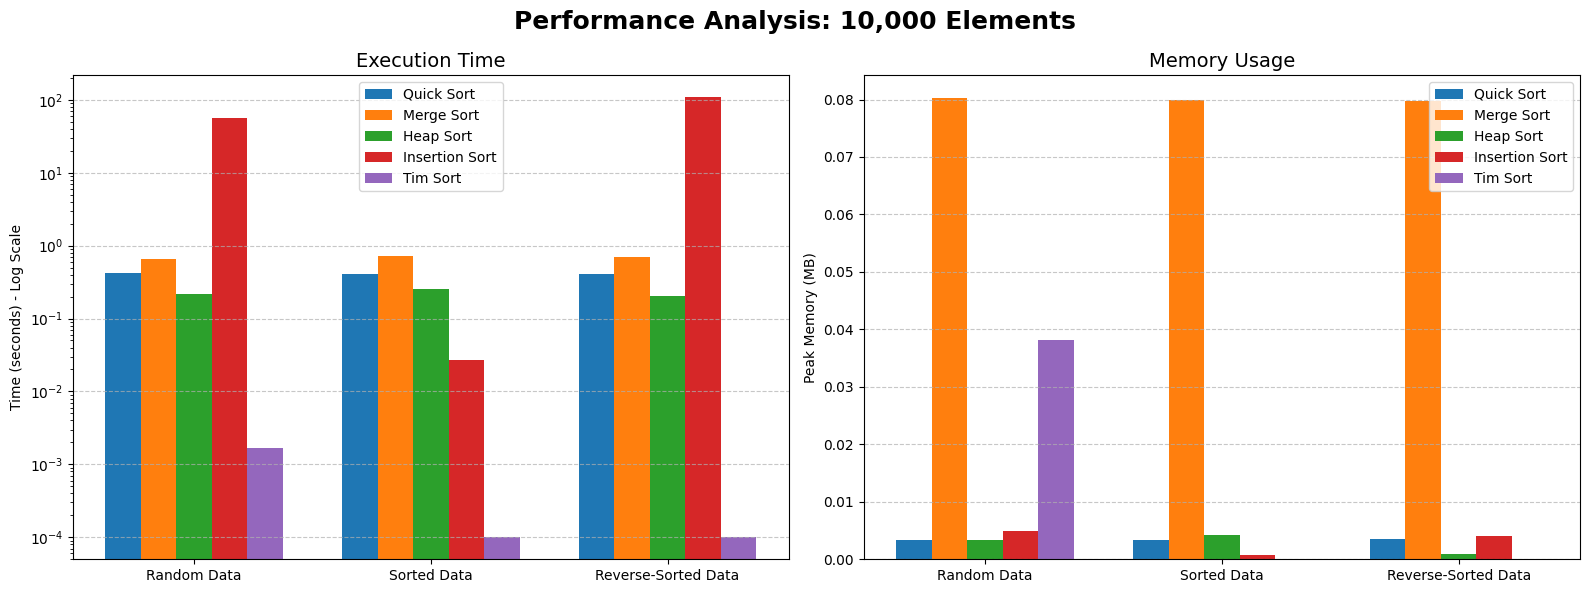

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA FOR 10,000 ELEMENTS ---
algorithms = ['Quick Sort', 'Merge Sort', 'Heap Sort', 'Insertion Sort', 'Tim Sort']
conditions = ['Random Data', 'Sorted Data', 'Reverse-Sorted Data']

# Execution Time (seconds)
time_data = {
    'Quick Sort': [0.4243, 0.4092, 0.4020],
    'Merge Sort': [0.6631, 0.7188, 0.7033],
    'Heap Sort': [0.2172, 0.2526, 0.2031],
    'Insertion Sort': [56.2091, 0.0273, 108.0631],
    'Tim Sort': [0.0017, 0.0001, 0.0001]
}

# Memory Usage (MB)
memory_data = {
    'Quick Sort': [0.0033, 0.0034, 0.0035],
    'Merge Sort': [0.0802, 0.0800, 0.0798],
    'Heap Sort': [0.0033, 0.0043, 0.0010],
    'Insertion Sort': [0.0049, 0.0008, 0.0041],
    'Tim Sort': [0.0381, 0.0000, 0.0000]
}

x = np.arange(len(conditions))
bar_width = 0.15

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Analysis: 10,000 Elements', fontsize=18, fontweight='bold')

# 1. Execution Time Subplot
for i, algo in enumerate(algorithms):
    axes[0].bar(x + (i - 2) * bar_width, time_data[algo], bar_width, label=algo)

axes[0].set_yscale('log')
axes[0].set_title('Execution Time', fontsize=14)
axes[0].set_ylabel('Time (seconds) - Log Scale')
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# 2. Memory Usage Subplot
for i, algo in enumerate(algorithms):
    axes[1].bar(x + (i - 2) * bar_width, memory_data[algo], bar_width, label=algo)

axes[1].set_title('Memory Usage', fontsize=14)
axes[1].set_ylabel('Peak Memory (MB)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

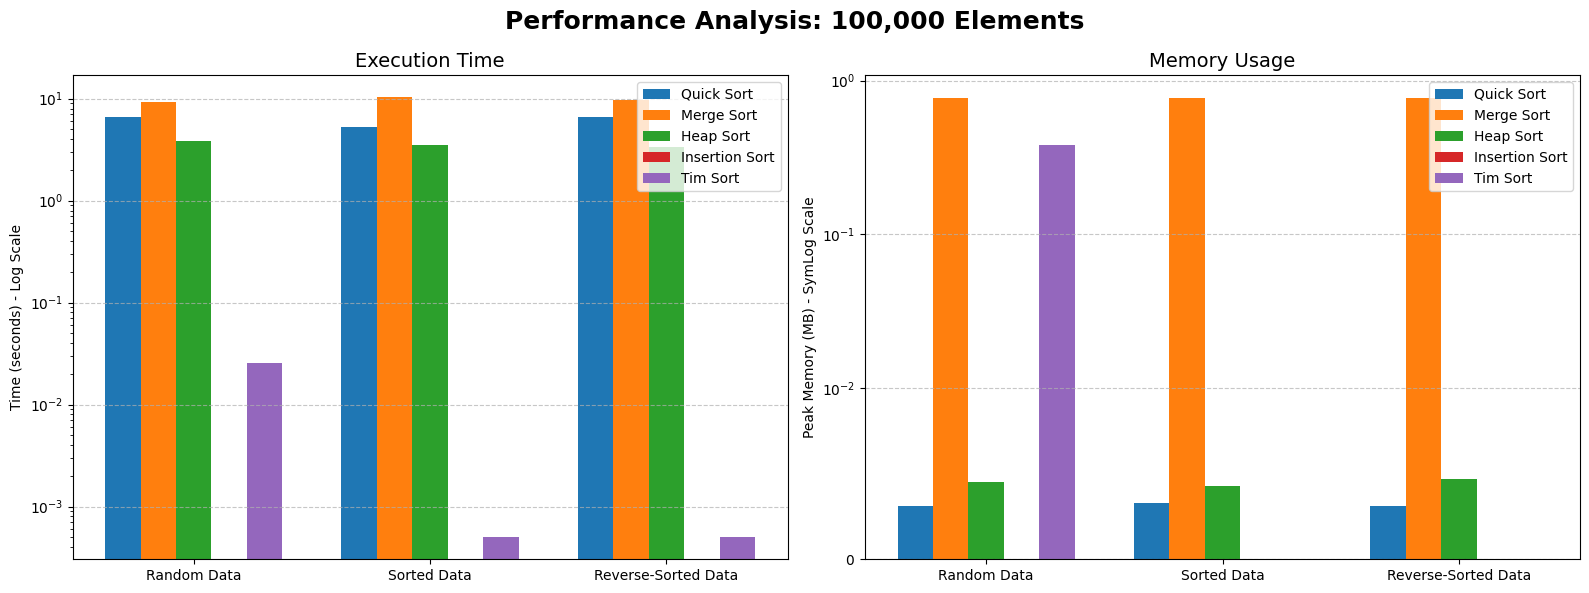

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA FOR 100,000 ELEMENTS ---
algorithms = ['Quick Sort', 'Merge Sort', 'Heap Sort', 'Insertion Sort', 'Tim Sort']
conditions = ['Random Data', 'Sorted Data', 'Reverse-Sorted Data']

# Execution Time (seconds) - 0 indicates "Too Slow"
time_data = {
    'Quick Sort': [6.6625, 5.2304, 6.6543],
    'Merge Sort': [9.3113, 10.2986, 9.6594],
    'Heap Sort': [3.8109, 3.5267, 3.3630],
    'Insertion Sort': [0, 0, 0],
    'Tim Sort': [0.0258, 0.0005, 0.0005]
}

# Memory Usage (MB) - 0 indicates "Too Slow"
memory_data = {
    'Quick Sort': [0.0031, 0.0033, 0.0031],
    'Merge Sort': [0.7667, 0.7669, 0.7667],
    'Heap Sort': [0.0045, 0.0043, 0.0047],
    'Insertion Sort': [0, 0, 0],
    'Tim Sort': [0.3813, 0.0000, 0.0000]
}

x = np.arange(len(conditions))
bar_width = 0.15

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Analysis: 100,000 Elements', fontsize=18, fontweight='bold')

# 1. Execution Time Subplot
for i, algo in enumerate(algorithms):
    axes[0].bar(x + (i - 2) * bar_width, time_data[algo], bar_width, label=algo)

axes[0].set_yscale('log')
axes[0].set_title('Execution Time', fontsize=14)
axes[0].set_ylabel('Time (seconds) - Log Scale')
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# 2. Memory Usage Subplot
for i, algo in enumerate(algorithms):
    axes[1].bar(x + (i - 2) * bar_width, memory_data[algo], bar_width, label=algo)

axes[1].set_yscale('symlog', linthresh=0.01) # Keeps 0s safe but graphs 0.7MB cleanly
axes[1].set_title('Memory Usage', fontsize=14)
axes[1].set_ylabel('Peak Memory (MB) - SymLog Scale')
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

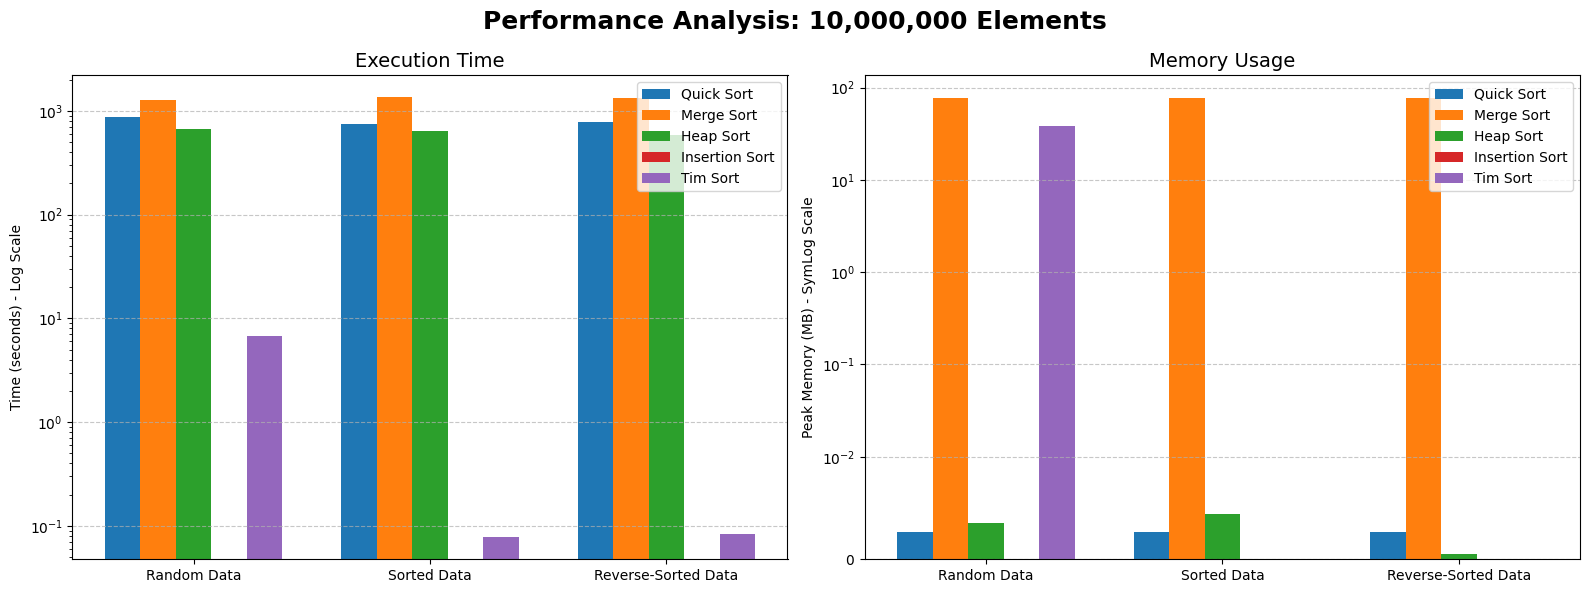

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA FOR 10,000,000 ELEMENTS ---
algorithms = ['Quick Sort', 'Merge Sort', 'Heap Sort', 'Insertion Sort', 'Tim Sort']
conditions = ['Random Data', 'Sorted Data', 'Reverse-Sorted Data']

# Execution Time (seconds) - 0 indicates "Too Slow"
time_data = {
    'Quick Sort': [866.8581, 753.3868, 778.9737],
    'Merge Sort': [1268.7251, 1351.7563, 1321.6039],
    'Heap Sort': [672.2513, 634.1163, 591.6618],
    'Insertion Sort': [0, 0, 0],
    'Tim Sort': [6.7444, 0.0777, 0.0827]
}

# Memory Usage (MB) - 0 indicates "Too Slow"
memory_data = {
    'Quick Sort': [0.0027, 0.0027, 0.0027],
    'Merge Sort': [76.2967, 76.2978, 76.2977],
    'Heap Sort': [0.0035, 0.0044, 0.0005],
    'Insertion Sort': [0, 0, 0],
    'Tim Sort': [38.1490, 0.0000, 0.0000]
}

x = np.arange(len(conditions))
bar_width = 0.15

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Analysis: 10,000,000 Elements', fontsize=18, fontweight='bold')

# 1. Execution Time Subplot
for i, algo in enumerate(algorithms):
    axes[0].bar(x + (i - 2) * bar_width, time_data[algo], bar_width, label=algo)

axes[0].set_yscale('log')
axes[0].set_title('Execution Time', fontsize=14)
axes[0].set_ylabel('Time (seconds) - Log Scale')
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# 2. Memory Usage Subplot
for i, algo in enumerate(algorithms):
    axes[1].bar(x + (i - 2) * bar_width, memory_data[algo], bar_width, label=algo)

axes[1].set_yscale('symlog', linthresh=0.01)
axes[1].set_title('Memory Usage', fontsize=14)
axes[1].set_ylabel('Peak Memory (MB) - SymLog Scale')
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()